# Defense Simulation

Simulate lightweight traffic-shaping defenses against the existing window-feature device classifier. The defenses are applied at the feature level after train/test splitting so the attack model is still trained on original traffic metadata.

- Padding: lift low-byte windows toward a fixed byte target learned from the training split.
- Smoothing: reduce short spikes by replacing each device's feature values with a centered rolling average.
- Padding + smoothing: apply both defenses to the test features.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

MIN_SAMPLES_PER_DEVICE = 10
FEATURE_COLS = [
    "pkt_count",
    "total_bytes",
    "outgoing_pkts",
    "incoming_pkts",
    "outgoing_bytes",
    "incoming_bytes",
    "avg_pkt_size",
    "max_pkt_size",
    "min_pkt_size",
]

input_path = "extracted_data"

feature_files = {
    "2018-03-20": f"input_path/features_2018_03_20.csv",
    "2018-03-21": f"input_path/features_2018_03_21.csv",
}

RANDOM_STATE = 42
PADDING_TARGET_QUANTILE = 0.75
SMOOTHING_WINDOW = 3

feature_tables = {day: pd.read_csv(path) for day, path in feature_files.items()}
for day, df in feature_tables.items():
    print(f"{day}: {df.shape[0]:,} windows, {df['label'].nunique()} devices")

2018-03-20: 257,070 windows, 45 devices
2018-03-21: 293,303 windows, 49 devices


['pkt_count',
 'total_bytes',
 'outgoing_pkts',
 'incoming_pkts',
 'outgoing_bytes',
 'incoming_bytes',
 'avg_pkt_size',
 'max_pkt_size',
 'min_pkt_size']

In [ ]:
def filter_labels_for_same_day(feature_df, min_samples=MIN_SAMPLES_PER_DEVICE):
    counts = feature_df["label"].value_counts()
    labels = counts[counts >= min_samples].index
    return feature_df[feature_df["label"].isin(labels)].copy()


def filter_common_labels(train_df, test_df, min_samples=MIN_SAMPLES_PER_DEVICE):
    train_counts = train_df["label"].value_counts()
    test_counts = test_df["label"].value_counts()
    labels = sorted(
        set(train_counts[train_counts >= min_samples].index)
        & set(test_counts[test_counts >= min_samples].index)
    )
    return (
        train_df[train_df["label"].isin(labels)].copy(),
        test_df[test_df["label"].isin(labels)].copy(),
        labels,
    )

In [2]:
COUNT_COLS = ["pkt_count", "outgoing_pkts", "incoming_pkts"]
BYTE_COLS = ["outgoing_bytes", "incoming_bytes"]
SIZE_COLS = ["avg_pkt_size", "max_pkt_size", "min_pkt_size"]
SMOOTH_COLS = COUNT_COLS + ["total_bytes"] + BYTE_COLS + SIZE_COLS


def normalize_feature_consistency(df):
    """Keep simple feature relationships sane after feature-level simulation."""
    adjusted = df.copy()
    for col in SMOOTH_COLS:
        adjusted[col] = (
            pd.to_numeric(adjusted[col], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
            .clip(lower=0)
        )

    adjusted["total_bytes"] = adjusted["outgoing_bytes"] + adjusted["incoming_bytes"]
    pkt_count = adjusted["pkt_count"].replace(0, np.nan)
    adjusted["avg_pkt_size"] = (
        adjusted["total_bytes"] / pkt_count
    ).replace([np.inf, -np.inf], np.nan).fillna(0)
    adjusted["max_pkt_size"] = np.maximum.reduce(
        [
            adjusted["max_pkt_size"].to_numpy(),
            adjusted["avg_pkt_size"].to_numpy(),
            adjusted["min_pkt_size"].to_numpy(),
        ]
    )
    adjusted["min_pkt_size"] = np.minimum(
        adjusted["min_pkt_size"], adjusted["avg_pkt_size"]
    )
    for col in FEATURE_COLS:
        adjusted[col] = adjusted[col].replace([np.inf, -np.inf], np.nan).fillna(0)
    return adjusted


def learn_padding_params(train_df, target_quantile=PADDING_TARGET_QUANTILE):
    active_bytes = pd.to_numeric(train_df["total_bytes"], errors="coerce")
    active_bytes = active_bytes.replace([np.inf, -np.inf], np.nan).dropna()
    active_bytes = active_bytes[active_bytes > 0]
    if active_bytes.empty:
        byte_target = 1.0
    else:
        byte_target = float(active_bytes.quantile(target_quantile))

    incoming = float(train_df["incoming_bytes"].sum())
    outgoing = float(train_df["outgoing_bytes"].sum())
    total = incoming + outgoing
    incoming_share = incoming / total if total else 0.5

    return {
        "byte_target": byte_target,
        "incoming_share": incoming_share,
        "outgoing_share": 1.0 - incoming_share,
    }


def apply_padding(df, params):
    defended = df.copy()
    shortfall = (params["byte_target"] - defended["total_bytes"]).clip(lower=0)
    defended["incoming_bytes"] = defended["incoming_bytes"] + (
        shortfall * params["incoming_share"]
    )
    defended["outgoing_bytes"] = defended["outgoing_bytes"] + (
        shortfall * params["outgoing_share"]
    )
    return normalize_feature_consistency(defended)


def apply_smoothing(df, window=SMOOTHING_WINDOW):
    defended = df.sort_values(["device", "window_start"]).copy()
    for col in SMOOTH_COLS:
        defended[col] = (
            defended.groupby("device", group_keys=False)[col]
            .rolling(window=window, center=True, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
    return normalize_feature_consistency(defended).sort_index()


def build_defense_variants(test_df, train_df):
    params = learn_padding_params(train_df)
    padded = apply_padding(test_df, params)
    smoothed = apply_smoothing(test_df)
    padded_smoothed = apply_smoothing(padded)
    return {
        "original": test_df.copy(),
        "padding": padded,
        "smoothing": smoothed,
        "padding_smoothing": padded_smoothed,
    }, params


In [3]:
def model_matrix(df):
    return df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)


def train_attack_model(train_df):
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(model_matrix(train_df), train_df["label"])
    return clf


def safe_name(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace("-", "")
        .replace(">", "to")
        .replace("+", "plus")
        .replace("/", "_")
    )


def evaluate_variant(experiment, variant, clf, test_df):
    y_true = test_df["label"]
    y_pred = clf.predict(model_matrix(test_df))
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    report = classification_report(y_true, y_pred, zero_division=0)
    matrix = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=clf.classes_),
        index=clf.classes_,
        columns=clf.classes_,
    )

    return {
        "experiment": experiment,
        "variant": variant,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "n_train": None,
        "n_test": len(test_df),
        "n_devices": y_true.nunique(),
    }


def evaluate_defense_suite(experiment, train_df, test_df):
    clf = train_attack_model(train_df)
    variants, params = build_defense_variants(test_df, train_df)
    rows = []
    for variant, variant_df in variants.items():
        row = evaluate_variant(experiment, variant, clf, variant_df)
        row["n_train"] = len(train_df)
        row["padding_byte_target"] = params["byte_target"]
        row["padding_incoming_share"] = params["incoming_share"]
        rows.append(row)
    return rows


## Same-Day and Cross-Day Experiments

In [4]:
all_rows = []

for day, df in feature_tables.items():
    filtered = filter_labels_for_same_day(df, min_samples=MIN_SAMPLES_PER_DEVICE)
    train_df, test_df = train_test_split(
        filtered,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=filtered["label"],
    )
    all_rows.extend(evaluate_defense_suite(f"Same-day {day}", train_df, test_df))

cross_day_pairs = [
    ("Train 2018-03-20 -> Test 2018-03-21", feature_tables["2018-03-20"], feature_tables["2018-03-21"]),
    ("Train 2018-03-21 -> Test 2018-03-20", feature_tables["2018-03-21"], feature_tables["2018-03-20"]),
]

for experiment, train_df, test_df in cross_day_pairs:
    train_filtered, test_filtered, labels = filter_common_labels(
        train_df, test_df, min_samples=MIN_SAMPLES_PER_DEVICE
    )
    all_rows.extend(evaluate_defense_suite(experiment, train_filtered, test_filtered))

summary = pd.DataFrame(all_rows)

baseline_accuracy = summary[summary["variant"] == "original"].set_index("experiment")["accuracy"]
baseline_f1 = summary[summary["variant"] == "original"].set_index("experiment")["macro_f1"]
summary["accuracy_drop_vs_original"] = summary["experiment"].map(baseline_accuracy) - summary["accuracy"]
summary["macro_f1_drop_vs_original"] = summary["experiment"].map(baseline_f1) - summary["macro_f1"]

summary.sort_values(["experiment", "variant"])


,experiment,variant,accuracy,macro_precision,macro_recall,macro_f1,n_train,n_test,n_devices,padding_byte_target,padding_incoming_share,accuracy_drop_vs_original,macro_f1_drop_vs_original
0,Same-day 2018-03-20,original,0.854242,0.791401,0.795658,0.776115,205652,51414,44,5282.75,0.148751,0.000000,0.000000
1,Same-day 2018-03-20,padding,0.350002,0.537575,0.236218,0.247408,205652,51414,44,5282.75,0.148751,0.504240,0.528708
3,Same-day 2018-03-20,padding_smoothing,0.308146,0.335114,0.183430,0.174825,205652,51414,44,5282.75,0.148751,0.546096,0.601290
2,Same-day 2018-03-20,smoothing,0.546291,0.426763,0.386826,0.367403,205652,51414,44,5282.75,0.148751,0.307951,0.408712
4,Same-day 2018-03-21,original,0.868974,0.791664,0.778282,0.763349,234638,58660,48,5815.00,0.130110,0.000000,0.000000
5,Same-day 2018-03-21,padding,0.353069,0.515185,0.194331,0.191753,234638,58660,48,5815.00,0.130110,0.515905,0.571596
7,Same-day 2018-03-21,padding_smoothing,0.305898,0.214786,0.149431,0.129388,234638,58660,48,5815.00,0.130110,0.563075,0.633961
6,Same-day 2018-03-21,smoothing,0.545823,0.459034,0.369040,0.376287,234638,58660,48,5815.00,0.130110,0.323150,0.387062
8,Train 2018-03-20 -> Test 2018-03-21,original,0.837106,0.780080,0.771379,0.748650,257066,290398,44,5261.00,0.147211,0.000000,0.000000
9,Train 2018-03-20 -> Test 2018-03-21,padding,0.350874,0.506776,0.201969,0.198411,257066,290398,44,5261.00,0.147211,0.486233,0.550239


## Metric Tables

In [5]:
accuracy_table = summary.pivot(index="experiment", columns="variant", values="accuracy")
macro_f1_table = summary.pivot(index="experiment", columns="variant", values="macro_f1")
drop_table = summary.pivot(index="experiment", columns="variant", values="macro_f1_drop_vs_original")

display(accuracy_table)
display(macro_f1_table)
display(drop_table)


variant,original,padding,padding_smoothing,smoothing
experiment,,,,
Same-day 2018-03-20,0.854242,0.350002,0.308146,0.546291
Same-day 2018-03-21,0.868974,0.353069,0.305898,0.545823
Train 2018-03-20 -> Test 2018-03-21,0.837106,0.350874,0.304379,0.513209
Train 2018-03-21 -> Test 2018-03-20,0.799849,0.308746,0.261194,0.492484


variant,original,padding,padding_smoothing,smoothing
experiment,,,,
Same-day 2018-03-20,0.776115,0.247408,0.174825,0.367403
Same-day 2018-03-21,0.763349,0.191753,0.129388,0.376287
Train 2018-03-20 -> Test 2018-03-21,0.748650,0.198411,0.130300,0.331362
Train 2018-03-21 -> Test 2018-03-20,0.661180,0.175609,0.117141,0.316324


variant,original,padding,padding_smoothing,smoothing
experiment,,,,
Same-day 2018-03-20,0.0,0.528708,0.601290,0.408712
Same-day 2018-03-21,0.0,0.571596,0.633961,0.387062
Train 2018-03-20 -> Test 2018-03-21,0.0,0.550239,0.618350,0.417288
Train 2018-03-21 -> Test 2018-03-20,0.0,0.485572,0.544040,0.344856


## Plots

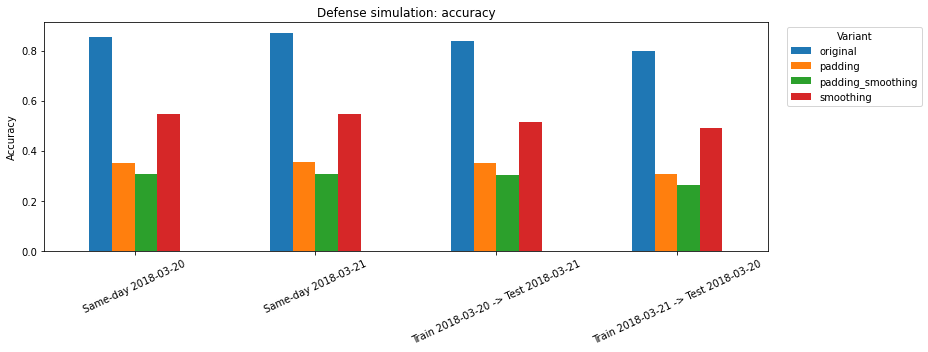

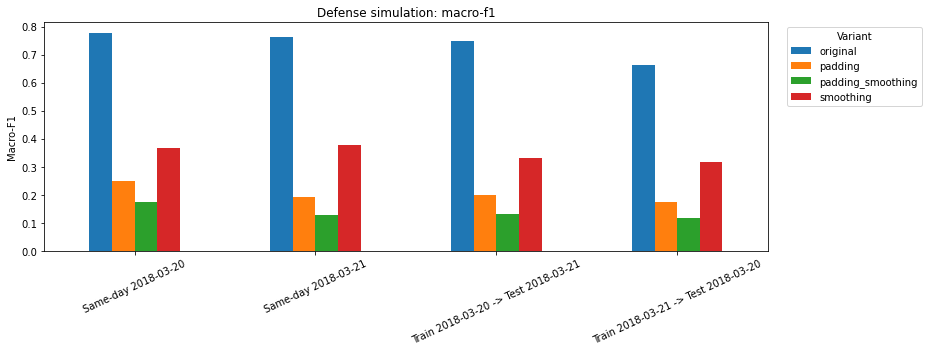

(PosixPath('cross_day_results/defense_simulation/defense_accuracy.png'),
 PosixPath('cross_day_results/defense_simulation/defense_macro_f1.png'))

In [6]:
def plot_metric(metric, ylabel):
    plot_df = summary.pivot(index="experiment", columns="variant", values=metric)
    ax = plot_df.plot(kind="bar", figsize=(13, 5), rot=25)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_title(f"Defense simulation: {ylabel.lower()}")
    ax.legend(title="Variant", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()
    return out_path


accuracy_plot = plot_metric("accuracy", "Accuracy")
f1_plot = plot_metric("macro_f1", "Macro-F1")

accuracy_plot, f1_plot


Positive drops mean the defense reduced attack performance relative to original test features. Negative drops mean the transformation accidentally made that split easier for the classifier.

In [7]:
summary2 = (
    summary[summary["variant"] != "original"]
    .sort_values("macro_f1_drop_vs_original", ascending=False)
    [
        [
            "experiment",
            "variant",
            "accuracy",
            "macro_f1",
            "accuracy_drop_vs_original",
            "macro_f1_drop_vs_original",
        ]
    ]
)

summary2

,experiment,variant,accuracy,macro_f1,accuracy_drop_vs_original,macro_f1_drop_vs_original
7,Same-day 2018-03-21,padding_smoothing,0.305898,0.129388,0.563075,0.633961
11,Train 2018-03-20 -> Test 2018-03-21,padding_smoothing,0.304379,0.130300,0.532727,0.618350
3,Same-day 2018-03-20,padding_smoothing,0.308146,0.174825,0.546096,0.601290
5,Same-day 2018-03-21,padding,0.353069,0.191753,0.515905,0.571596
9,Train 2018-03-20 -> Test 2018-03-21,padding,0.350874,0.198411,0.486233,0.550239
15,Train 2018-03-21 -> Test 2018-03-20,padding_smoothing,0.261194,0.117141,0.538655,0.544040
1,Same-day 2018-03-20,padding,0.350002,0.247408,0.504240,0.528708
13,Train 2018-03-21 -> Test 2018-03-20,padding,0.308746,0.175609,0.491103,0.485572
10,Train 2018-03-20 -> Test 2018-03-21,smoothing,0.513209,0.331362,0.323897,0.417288
2,Same-day 2018-03-20,smoothing,0.546291,0.367403,0.307951,0.408712


Saved summary and per-variant reports in: cross_day_results/defense_simulation
